# MmarakaAI Stage B Classical Machine Learning

This notebook is the primary reproducible benchmarking workflow for classical machine learning experiments in MmarakaAI.

It uses the Stage A cleaned feature matrix, performs model-based Stage B feature selection with Random Forest feature importance, benchmarks Random Forest and LightGBM across multiple top-N feature subsets, and evaluates the winning baseline on a held-out chronological test set.


## 1. Environment Setup

The workflow is designed to run locally or in Google Colab. In Colab, missing packages are installed automatically. Locally, the notebook expects dependencies to be installed in the active environment and raises a clear message if they are missing.


In [54]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

PROJECT_NAME = "MmarakaAI"
REPOSITORY_URL = "https://github.com/Wiz-Tech-Kid/MmarakaAI.git"

try:
    import google.colab  # type: ignore[import-not-found]
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# In Colab, clone the project into /content and make it the working directory.
# Locally, keep the existing repository working directory unchanged.
if IN_COLAB:
    colab_root = Path("/content")
    project_root = colab_root / PROJECT_NAME
    if not project_root.exists():
        subprocess.check_call(["git", "clone", REPOSITORY_URL, str(project_root)])
    os.chdir(project_root)
else:
    current_path = Path.cwd().resolve()
    local_root = next(
        (candidate for candidate in [current_path, *current_path.parents] if (candidate / "data").is_dir() and (candidate / "src").is_dir()),
        None,
    )
    if local_root is not None:
        os.chdir(local_root)

ROOT = Path.cwd().resolve()
print(f"Running in {'Google Colab' if IN_COLAB else 'local VS Code'}")
print(f"Project root: {ROOT}")

if not (ROOT / "data").is_dir() or not (ROOT / "src").is_dir():
    raise FileNotFoundError(
        "The MmarakaAI repository was not found. In Colab, rerun this cell so it can clone the repository."
    )

REQUIREMENTS_PATH = ROOT / "requirements.txt"
if not REQUIREMENTS_PATH.exists():
    raise FileNotFoundError(f"Missing requirements file: {REQUIREMENTS_PATH}")

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "lightgbm": "lightgbm",
    "joblib": "joblib",
    "IPython": "ipython",
}
missing_packages = [
    pip_name
    for module_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages and IN_COLAB:
    print(f"Installing missing packages from {REQUIREMENTS_PATH.name}: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(REQUIREMENTS_PATH)])
elif missing_packages:
    raise ImportError(
        "Missing required packages: "
        + ", ".join(missing_packages)
        + ". Install them locally with: .venv/bin/pip install -r requirements.txt"
    )

print("Repository and dependencies verified")

Running in Google Colab
Project root: /content/MmarakaAI
Repository and dependencies verified


## 2. Imports, Configuration, and Paths

All randomness is controlled with a fixed seed. Paths are resolved by walking upward from the current working directory until the project data file is found, so the notebook can be launched from the repository root or from the `notebooks/` directory.


In [55]:
import logging
import math
import time
import warnings
from dataclasses import dataclass
from typing import Callable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_SEED = 42
TARGET_COLUMN = "food_price_inflation"
DATE_COLUMN = "Date"
TEST_SIZE = 0.20
CV_SPLITS = 5
TOP_N_OPTIONS = [25, 50, 100, 200, 500]

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger("mmarakai_stage_b")
np.random.seed(RANDOM_SEED)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        expected = candidate / "data" / "features" / "mmarakai_clean_feature_matrix.csv"
        if expected.exists():
            return candidate
    raise FileNotFoundError("Could not find data/features/mmarakai_clean_feature_matrix.csv from the current path.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "features" / "mmarakai_clean_feature_matrix.csv"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURE_DIR = OUTPUT_DIR / "analysis" / "figures" / "ml"

MODEL_PATH = MODELS_DIR / "stageB_best_classic_ml_model.joblib"
SELECTED_FEATURES_PATH = OUTPUT_DIR / "selected_features.csv"
FEATURE_IMPORTANCE_PATH = OUTPUT_DIR / "feature_importance.csv"
MODEL_COMPARISON_PATH = OUTPUT_DIR / "model_comparison.csv"
FINAL_METRICS_PATH = OUTPUT_DIR / "final_test_metrics.csv"

for directory in [MODELS_DIR, OUTPUT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

logger.info("Project root: %s", PROJECT_ROOT)
logger.info("Input data: %s", DATA_PATH)


## 3. Load and Validate the Stage A Clean Feature Matrix

`Date` is retained for chronological sorting and plotting, but it is not used as a predictor. The target is `food_price_inflation`.


In [56]:
from pathlib import Path
import logging

import numpy as np
import pandas as pd

if "TARGET_COLUMN" not in globals():
    TARGET_COLUMN = "food_price_inflation"
if "DATE_COLUMN" not in globals():
    DATE_COLUMN = "Date"

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    search_roots = [
        start,
        *start.parents,
        Path("/content") / "MmarakaAI",
        Path.home() / "Documents" / "New Folder" / "MmarakaAI",
    ]
    for root in search_roots:
        expected = root / "data" / "features" / "mmarakai_clean_feature_matrix.csv"
        if expected.exists():
            return root
    raise FileNotFoundError(
        "Could not find data/features/mmarakai_clean_feature_matrix.csv. "
        "Run the environment setup cell first or open the notebook from the project directory."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "features" / "mmarakai_clean_feature_matrix.csv"
if "logger" not in globals():
    logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
    logger = logging.getLogger("mmarakai_stage_b")

logger.info("Loading Stage A clean feature matrix")
data = pd.read_csv(DATA_PATH)
if DATE_COLUMN not in data.columns:
    raise KeyError(f"Missing required date column: {DATE_COLUMN}")
if TARGET_COLUMN not in data.columns:
    raise KeyError(f"Missing required target column: {TARGET_COLUMN}")

data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN], errors="coerce")
if data[DATE_COLUMN].isna().any():
    raise ValueError("Date column contains unparseable values.")
data = data.sort_values(DATE_COLUMN, kind="mergesort").reset_index(drop=True)

if data[TARGET_COLUMN].isna().any():
    raise ValueError("Target column contains missing values. Resolve target missingness before model training.")
if data[DATE_COLUMN].duplicated().any():
    raise ValueError("Date column contains duplicate timestamps.")

dates = data[DATE_COLUMN].copy()
y = data[TARGET_COLUMN].astype(float).copy()
X = data.drop(columns=[DATE_COLUMN, TARGET_COLUMN]).copy()

non_numeric_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric_columns:
    logger.warning("Converting %d non-numeric predictor columns to numeric with coercion.", len(non_numeric_columns))
    for column in non_numeric_columns:
        X[column] = pd.to_numeric(X[column], errors="coerce")

infinite_feature_count = int(np.isinf(X.to_numpy(dtype=float)).sum())
if infinite_feature_count:
    logger.warning("Replacing %d infinite feature values with NaN for median imputation.", infinite_feature_count)
    X = X.replace([np.inf, -np.inf], np.nan)

logger.info("Rows: %d | Predictors: %d | Target: %s", len(data), X.shape[1], TARGET_COLUMN)
logger.info("Date range: %s to %s", dates.min().date(), dates.max().date())
display(data[[DATE_COLUMN, TARGET_COLUMN]].head())
display(X.describe().T[["count", "mean", "std", "min", "max"]].head(10))

,Date,food_price_inflation
0,2000-01-01,3.602384
1,2000-02-01,3.602384
2,2000-03-01,3.602384
3,2000-04-01,3.602384
4,2000-05-01,3.602384


,count,mean,std,min,max
food_index,288.0,81.418189,32.723337,31.912372,149.353957
general_index,288.0,82.270026,32.815469,31.748320,146.861601
Brent_USD_per_barrel,288.0,66.114792,29.208779,18.380000,132.720000
policy_rate,288.0,11.586285,2.467477,1.650000,14.000000
BDI_Close_mean,288.0,2239.809670,1916.274769,312.120000,10964.125000
BDI_Close_median,288.0,2238.662182,1916.413611,311.600000,10957.125000
BDI_Close_min,288.0,2002.107639,1760.137043,290.000000,9897.000000
BDI_Close_max,288.0,2484.659722,2092.199607,349.000000,11793.000000
BDI_Close_range,288.0,130.438831,125.660073,4.500000,806.750000
BDI_Close_std,288.0,48.672980,47.071769,1.688968,313.048048


## 4. Chronological Train/Test Split

This is a forecasting problem, so the test set is the most recent 20% of observations. No random shuffling is used anywhere in the split or cross-validation workflow.


In [57]:
split_index = int(len(data) * (1 - TEST_SIZE))
if split_index <= CV_SPLITS + 5 or split_index >= len(data):
    raise ValueError("Dataset is too small for the configured chronological split and TimeSeriesSplit.")

X_train = X.iloc[:split_index].copy()
y_train = y.iloc[:split_index].copy()
dates_train = dates.iloc[:split_index].copy()

X_test = X.iloc[split_index:].copy()
y_test = y.iloc[split_index:].copy()
dates_test = dates.iloc[split_index:].copy()

logger.info("Training rows: %d (%s to %s)", len(X_train), dates_train.min().date(), dates_train.max().date())
logger.info("Test rows: %d (%s to %s)", len(X_test), dates_test.min().date(), dates_test.max().date())

pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "start_date": [dates_train.min(), dates_test.min()],
        "end_date": [dates_train.max(), dates_test.max()],
    }
)


,split,rows,start_date,end_date
0,train,230,2000-01-01,2019-02-01
1,test,58,2019-03-01,2023-12-01


## 5. Stage B Model-Based Feature Selection

A Random Forest Regressor is trained on the chronological training set using all predictors. Its feature importances are used only to rank features for benchmarking top-N subsets. This is model-based feature selection, not correlation filtering.


In [58]:
import time

import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

required_variables = {
    "RANDOM_SEED": "the imports/configuration cell",
    "X_train": "the chronological train/test split cell",
    "y_train": "the chronological train/test split cell",
    "FEATURE_IMPORTANCE_PATH": "the imports/configuration cell",
}
missing_variables = [name for name in required_variables if name not in globals()]
if missing_variables:
    missing_steps = sorted({required_variables[name] for name in missing_variables})
    raise RuntimeError(
        "Cell 5 requires earlier cells to run first. Missing: "
        + ", ".join(missing_variables)
        + ". Run the notebook from the top, or run: "
        + " -> ".join(missing_steps)
        + "."
    )


def make_random_forest(n_estimators: int = 400) -> RandomForestRegressor:
    return RandomForestRegressor(
        n_estimators=n_estimators,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        min_samples_leaf=2,
        max_features="sqrt",
    )


def make_lgbm() -> LGBMRegressor:
    return LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1,
    )


def make_pipeline(model):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", model),
        ]
    )

logger.info("Training initial Random Forest on all %d predictors for feature ranking", X_train.shape[1])
importance_pipeline = make_pipeline(make_random_forest(n_estimators=500))
importance_start = time.perf_counter()
importance_pipeline.fit(X_train, y_train)
importance_time = time.perf_counter() - importance_start
logger.info("Feature ranking model trained in %.2f seconds", importance_time)

feature_importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": importance_pipeline.named_steps["model"].feature_importances_,
    }
).sort_values("importance", ascending=False, kind="mergesort").reset_index(drop=True)
feature_importance.insert(0, "rank", np.arange(1, len(feature_importance) + 1))
feature_importance.to_csv(FEATURE_IMPORTANCE_PATH, index=False)

logger.info("Saved feature importance ranking to %s", FEATURE_IMPORTANCE_PATH)
display(feature_importance.head(25))

,rank,feature,importance
0,1,food_index_std12,0.015292
1,2,BDI_High_median_std12,0.015203
2,3,BDI_Close_variance_std12,0.014689
3,4,BDI_High_std_std12,0.013786
4,5,BDI_Low_median_std12,0.012255
5,6,BDI_High_variance_std12,0.012148
6,7,PI201135_std12,0.011822
7,8,BDI_Low_variance_std12,0.011508
8,9,BDI_Close_last_std12,0.011252
9,10,BDI_Low_std_std12,0.011213


## 6. TimeSeriesSplit Cross-Validation Experiments

Each top-N feature subset is evaluated with two baseline models: Random Forest Regressor and LightGBM Regressor. Metrics are averaged across expanding-window `TimeSeriesSplit` folds.


In [59]:
def compute_metrics(y_true, y_pred) -> dict[str, float]:
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"mae": mae, "rmse": rmse, "r2": r2}

def evaluate_model_cv(model_name: str, model_factory: Callable[[], object], features: list[str], subset_label: str) -> dict[str, float | str | int]:
    tscv = TimeSeriesSplit(n_splits=CV_SPLITS)
    fold_rows: list[dict[str, float]] = []
    X_subset = X_train[features]

    for fold, (train_index, valid_index) in enumerate(tscv.split(X_subset), start=1):
        X_fold_train = X_subset.iloc[train_index]
        y_fold_train = y_train.iloc[train_index]
        X_fold_valid = X_subset.iloc[valid_index]
        y_fold_valid = y_train.iloc[valid_index]

        pipeline = make_pipeline(model_factory())
        start_time = time.perf_counter()
        pipeline.fit(X_fold_train, y_fold_train)
        train_time = time.perf_counter() - start_time
        predictions = pipeline.predict(X_fold_valid)
        metrics = compute_metrics(y_fold_valid, predictions)
        fold_rows.append({**metrics, "training_time_seconds": train_time})

    fold_metrics = pd.DataFrame(fold_rows)
    return {
        "model": model_name,
        "feature_subset": subset_label,
        "n_features": len(features),
        "mae": float(fold_metrics["mae"].mean()),
        "mae_std": float(fold_metrics["mae"].std(ddof=0)),
        "rmse": float(fold_metrics["rmse"].mean()),
        "rmse_std": float(fold_metrics["rmse"].std(ddof=0)),
        "r2": float(fold_metrics["r2"].mean()),
        "r2_std": float(fold_metrics["r2"].std(ddof=0)),
        "training_time_seconds": float(fold_metrics["training_time_seconds"].sum()),
    }

model_factories: dict[str, Callable[[], object]] = {
    "RandomForestRegressor": lambda: make_random_forest(n_estimators=300),
    "LightGBMRegressor": make_lgbm,
}

experiment_results: list[dict[str, float | str | int]] = []
ranked_features = feature_importance["feature"].tolist()
for top_n in TOP_N_OPTIONS:
    selected = ranked_features[: min(top_n, len(ranked_features))]
    subset_label = f"top_{top_n}"
    logger.info("Evaluating subset %s with %d features", subset_label, len(selected))
    for model_name, factory in model_factories.items():
        logger.info("  Model: %s", model_name)
        result = evaluate_model_cv(model_name, factory, selected, subset_label)
        experiment_results.append(result)

model_comparison = pd.DataFrame(experiment_results).sort_values(
    ["rmse", "mae"], ascending=[True, True], kind="mergesort"
).reset_index(drop=True)
model_comparison.insert(0, "rank", np.arange(1, len(model_comparison) + 1))
model_comparison.to_csv(MODEL_COMPARISON_PATH, index=False)

logger.info("Saved model comparison table to %s", MODEL_COMPARISON_PATH)
display(model_comparison)


,rank,model,feature_subset,n_features,mae,mae_std,rmse,rmse_std,r2,r2_std,training_time_seconds
0,1,LightGBMRegressor,top_100,100,2.737743,1.390009,3.355548,1.854392,-0.231578,0.429217,0.501583
1,2,LightGBMRegressor,top_200,200,2.965141,1.673867,3.542380,2.097731,-0.535160,1.107304,0.819534
2,3,LightGBMRegressor,top_50,50,2.885030,1.232234,3.554633,1.714718,-0.462814,0.505601,0.308482
3,4,LightGBMRegressor,top_25,25,3.066686,1.236721,3.752455,1.693242,-0.826290,1.225917,0.627979
4,5,RandomForestRegressor,top_25,25,3.533263,1.526759,4.172753,1.919376,-1.340023,1.280700,2.884366
5,6,RandomForestRegressor,top_100,100,3.411006,1.843998,4.207475,2.377700,-1.129302,1.042961,2.451595
6,7,RandomForestRegressor,top_50,50,3.565515,1.579754,4.317187,1.991056,-1.440290,1.282766,2.626057
7,8,RandomForestRegressor,top_200,200,3.886817,1.884417,4.579302,2.365356,-1.796302,1.932530,2.562347
8,9,LightGBMRegressor,top_500,500,4.263737,3.077736,4.828779,3.194824,-3.978281,7.604871,1.885343
9,10,RandomForestRegressor,top_500,500,4.454670,2.547124,5.029232,2.746436,-3.533801,5.632964,3.866945


## 7. Select and Retrain the Winning Baseline

The best combination is selected by lowest cross-validated RMSE, with MAE as the tie-breaker. The winning model is then retrained on the full chronological training set using only its selected feature subset.


In [60]:
best_row = model_comparison.iloc[0].copy()
best_model_name = str(best_row["model"])
best_n_features = int(best_row["n_features"])
best_subset_label = str(best_row["feature_subset"])
selected_features = ranked_features[:best_n_features]

selected_features_df = pd.DataFrame(
    {
        "selected_rank": np.arange(1, len(selected_features) + 1),
        "feature": selected_features,
    }
).merge(feature_importance[["feature", "rank", "importance"]], on="feature", how="left")
selected_features_df.to_csv(SELECTED_FEATURES_PATH, index=False)
logger.info("Saved selected feature list to %s", SELECTED_FEATURES_PATH)

best_factory = model_factories[best_model_name]
final_model = make_pipeline(best_factory())
logger.info("Retraining winning model: %s with %d features", best_model_name, best_n_features)
final_train_start = time.perf_counter()
final_model.fit(X_train[selected_features], y_train)
final_training_time = time.perf_counter() - final_train_start
logger.info("Final model trained in %.2f seconds", final_training_time)


## 8. Held-Out Test Evaluation

The final test set is the most recent chronological block and is not used for feature ranking, cross-validation, or model selection.


In [61]:
test_predictions = final_model.predict(X_test[selected_features])
residuals = y_test.to_numpy() - test_predictions
final_metrics = compute_metrics(y_test, test_predictions)
final_metrics["training_time_seconds"] = final_training_time

final_metrics_df = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "feature_subset": best_subset_label,
            "n_features": best_n_features,
            "test_mae": final_metrics["mae"],
            "test_rmse": final_metrics["rmse"],
            "test_r2": final_metrics["r2"],
            "training_time_seconds": final_metrics["training_time_seconds"],
        }
    ]
)
final_metrics_df.to_csv(FINAL_METRICS_PATH, index=False)
logger.info("Saved final test metrics to %s", FINAL_METRICS_PATH)
display(final_metrics_df)

prediction_frame = pd.DataFrame(
    {
        DATE_COLUMN: dates_test.to_numpy(),
        "actual": y_test.to_numpy(),
        "predicted": test_predictions,
        "residual": residuals,
    }
)
display(prediction_frame.head())


,model,feature_subset,n_features,test_mae,test_rmse,test_r2,training_time_seconds
0,LightGBMRegressor,top_100,100,2.850621,4.29543,0.271978,0.213601


,Date,actual,predicted,residual
0,2019-03-01,0.115759,0.524277,-0.408518
1,2019-04-01,0.414577,1.978846,-1.564269
2,2019-05-01,1.008746,2.718511,-1.709765
3,2019-06-01,1.304094,2.741833,-1.437739
4,2019-07-01,1.601465,2.976451,-1.374986


## 9. Diagnostic Plots

The notebook saves actual-vs-predicted, residual, feature-importance, and learning-curve figures into `output/analysis/figures/ml`.


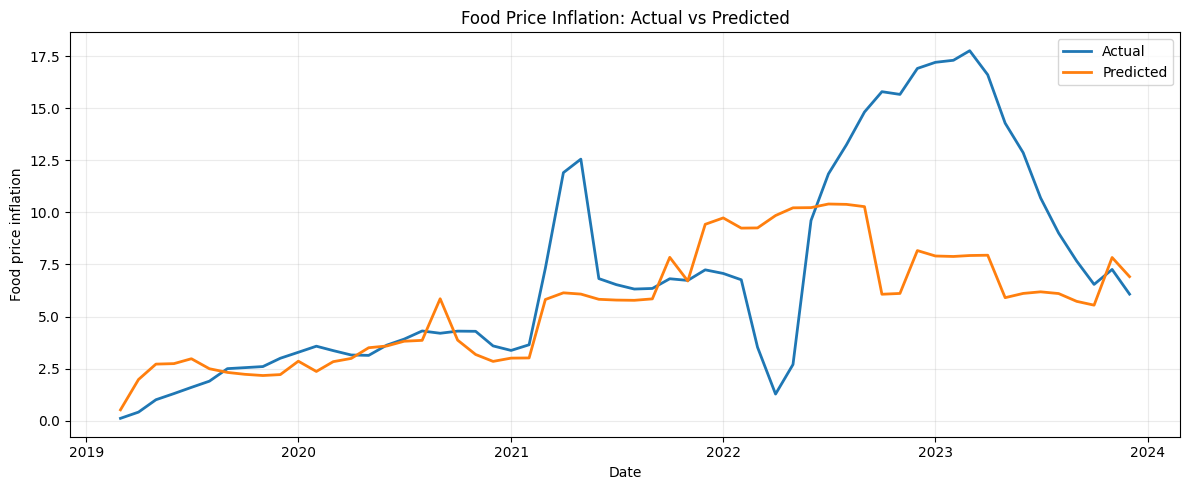

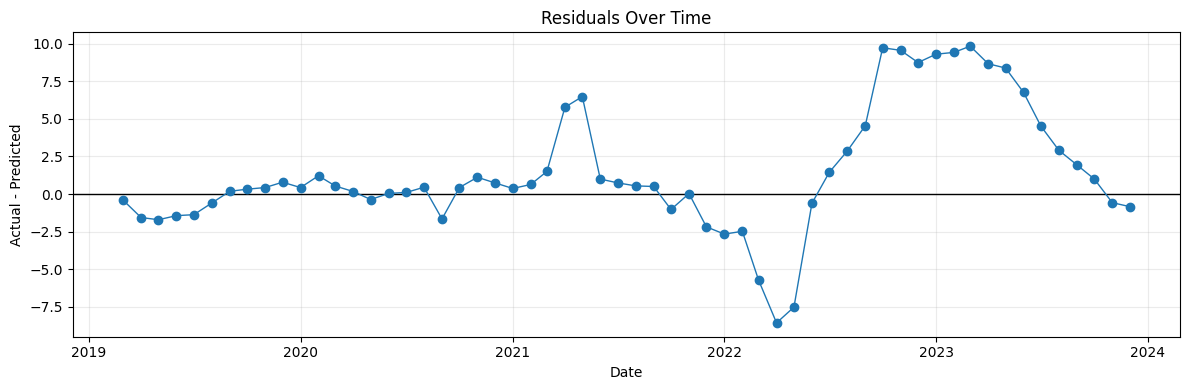

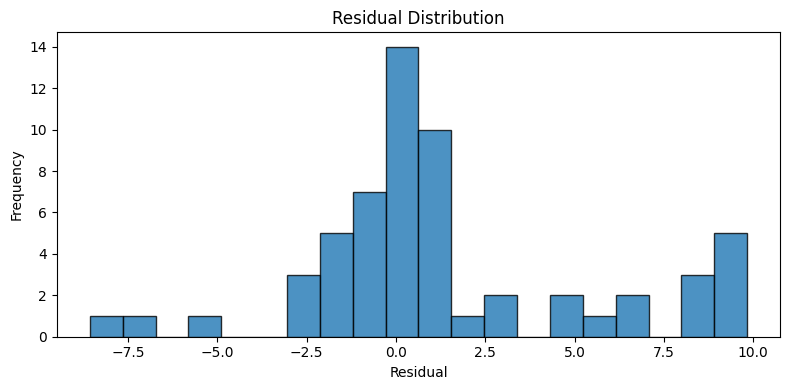

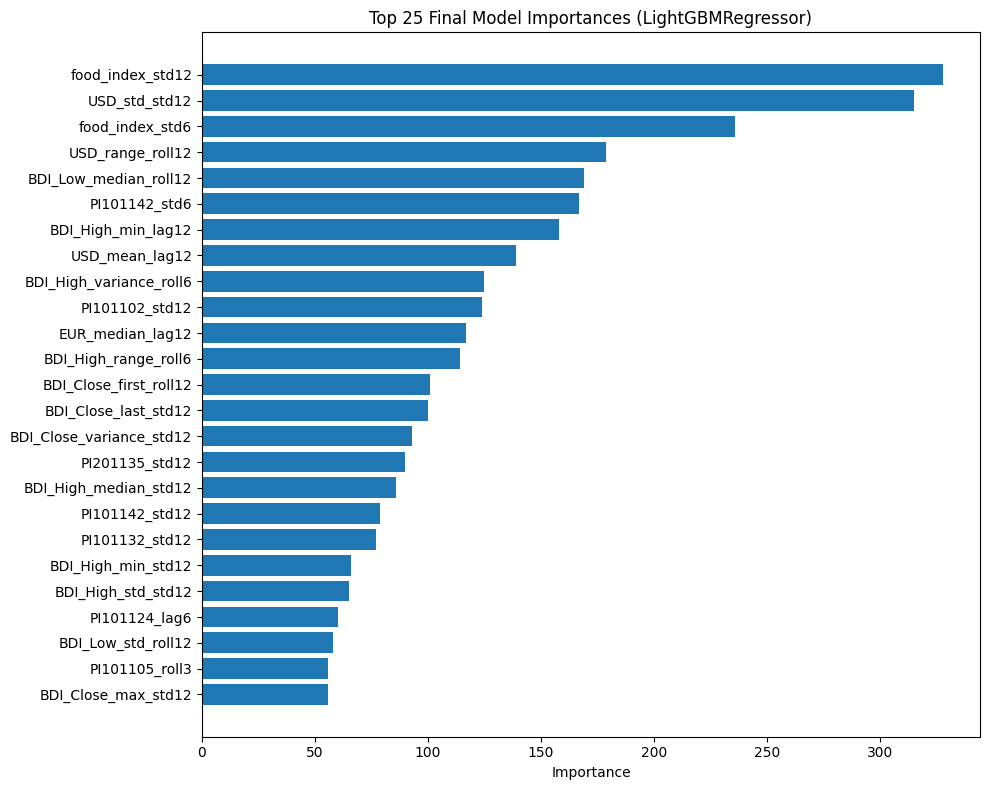

In [62]:
def save_current_figure(filename: str) -> Path:
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    logger.info("Saved figure: %s", path)
    plt.show()
    return path

plt.figure(figsize=(12, 5))
plt.plot(prediction_frame[DATE_COLUMN], prediction_frame["actual"], label="Actual", linewidth=2)
plt.plot(prediction_frame[DATE_COLUMN], prediction_frame["predicted"], label="Predicted", linewidth=2)
plt.title("Food Price Inflation: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Food price inflation")
plt.legend()
plt.grid(alpha=0.25)
actual_predicted_path = save_current_figure("stageB_actual_vs_predicted.png")

plt.figure(figsize=(12, 4))
plt.axhline(0, color="black", linewidth=1)
plt.plot(prediction_frame[DATE_COLUMN], prediction_frame["residual"], marker="o", linewidth=1)
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.grid(alpha=0.25)
residual_time_path = save_current_figure("stageB_residuals_over_time.png")

plt.figure(figsize=(8, 4))
plt.hist(prediction_frame["residual"], bins=20, edgecolor="black", alpha=0.8)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
residual_hist_path = save_current_figure("stageB_residual_distribution.png")

final_estimator = final_model.named_steps["model"]
if hasattr(final_estimator, "feature_importances_"):
    final_importance = pd.DataFrame(
        {
            "feature": selected_features,
            "importance": final_estimator.feature_importances_,
        }
    ).sort_values("importance", ascending=False, kind="mergesort")
    top_plot = final_importance.head(25).sort_values("importance", ascending=True)
    plt.figure(figsize=(10, 8))
    plt.barh(top_plot["feature"], top_plot["importance"])
    plt.title(f"Top 25 Final Model Importances ({best_model_name})")
    plt.xlabel("Importance")
    feature_importance_plot_path = save_current_figure("stageB_final_model_feature_importance.png")
else:
    logger.warning("Winning model does not expose feature_importances_; skipping importance plot.")
    feature_importance_plot_path = None


## 10. Learning Curve

This time-aware learning curve trains on growing prefixes of the training period and evaluates on the final validation block within the training period. It does not shuffle observations.


,training_rows,train_rmse,validation_rmse,training_time_seconds
0,55,0.324982,2.718459,0.037997
1,80,0.382000,4.190985,0.064721
2,106,0.501503,5.272611,0.069550
3,132,0.339457,3.283911,0.102028
4,158,0.284135,3.884705,0.130984
5,184,0.268003,1.797768,0.164571


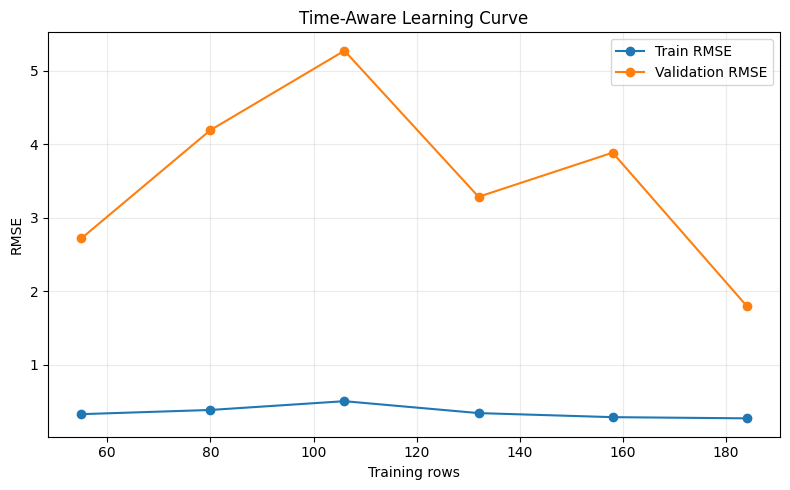

In [63]:
validation_start = int(len(X_train) * 0.80)
X_learning_train = X_train.iloc[:validation_start][selected_features]
y_learning_train = y_train.iloc[:validation_start]
X_learning_valid = X_train.iloc[validation_start:][selected_features]
y_learning_valid = y_train.iloc[validation_start:]

learning_rows = []
train_sizes = np.linspace(0.30, 1.00, 6)
for fraction in train_sizes:
    n_rows = max(12, int(len(X_learning_train) * fraction))
    model = make_pipeline(best_factory())
    start_time = time.perf_counter()
    model.fit(X_learning_train.iloc[:n_rows], y_learning_train.iloc[:n_rows])
    train_time = time.perf_counter() - start_time
    train_pred = model.predict(X_learning_train.iloc[:n_rows])
    valid_pred = model.predict(X_learning_valid)
    learning_rows.append(
        {
            "training_rows": n_rows,
            "train_rmse": math.sqrt(mean_squared_error(y_learning_train.iloc[:n_rows], train_pred)),
            "validation_rmse": math.sqrt(mean_squared_error(y_learning_valid, valid_pred)),
            "training_time_seconds": train_time,
        }
    )

learning_curve = pd.DataFrame(learning_rows)
display(learning_curve)

plt.figure(figsize=(8, 5))
plt.plot(learning_curve["training_rows"], learning_curve["train_rmse"], marker="o", label="Train RMSE")
plt.plot(learning_curve["training_rows"], learning_curve["validation_rmse"], marker="o", label="Validation RMSE")
plt.title("Time-Aware Learning Curve")
plt.xlabel("Training rows")
plt.ylabel("RMSE")
plt.legend()
plt.grid(alpha=0.25)
learning_curve_path = save_current_figure("stageB_learning_curve.png")


## 11. Save Trained Model Artifact

The saved artifact includes the fitted preprocessing/model pipeline, selected feature names, target/date metadata, and final test metrics.


In [64]:
model_artifact = {
    "pipeline": final_model,
    "model_name": best_model_name,
    "selected_features": selected_features,
    "target_column": TARGET_COLUMN,
    "date_column": DATE_COLUMN,
    "feature_subset": best_subset_label,
    "n_features": best_n_features,
    "cv_selection_row": best_row.to_dict(),
    "final_test_metrics": final_metrics_df.iloc[0].to_dict(),
    "random_seed": RANDOM_SEED,
}
joblib.dump(model_artifact, MODEL_PATH)
logger.info("Saved trained model artifact to %s", MODEL_PATH)
MODEL_PATH


PosixPath('/content/MmarakaAI/models/stageB_best_classic_ml_model.joblib')

## 12. Final Summary

This cell prints the winning baseline, selected feature count, final held-out test metrics, and artifact locations.


In [65]:
summary = {
    "best_model": best_model_name,
    "optimal_feature_subset": best_subset_label,
    "selected_feature_count": best_n_features,
    "cv_rmse": float(best_row["rmse"]),
    "cv_mae": float(best_row["mae"]),
    "test_rmse": float(final_metrics["rmse"]),
    "test_mae": float(final_metrics["mae"]),
    "test_r2": float(final_metrics["r2"]),
    "model_path": str(MODEL_PATH),
    "selected_features_path": str(SELECTED_FEATURES_PATH),
    "feature_importance_path": str(FEATURE_IMPORTANCE_PATH),
    "model_comparison_path": str(MODEL_COMPARISON_PATH),
    "figures_dir": str(FIGURE_DIR),
}
summary_df = pd.DataFrame([summary])
display(summary_df.T.rename(columns={0: "value"}))

print("Stage B complete.")
print(f"Best baseline model: {best_model_name}")
print(f"Optimal number of selected features: {best_n_features}")
print(f"Final test RMSE: {final_metrics['rmse']:.4f}")
print(f"Final test MAE: {final_metrics['mae']:.4f}")
print(f"Final test R2: {final_metrics['r2']:.4f}")


,value
best_model,LightGBMRegressor
optimal_feature_subset,top_100
selected_feature_count,100
cv_rmse,3.355548
cv_mae,2.737743
test_rmse,4.29543
test_mae,2.850621
test_r2,0.271978
model_path,/content/MmarakaAI/models/stageB_best_classic_...
selected_features_path,/content/MmarakaAI/output/selected_features.csv


Stage B complete.
Best baseline model: LightGBMRegressor
Optimal number of selected features: 100
Final test RMSE: 4.2954
Final test MAE: 2.8506
Final test R2: 0.2720


In [67]:
from pathlib import Path

REPORT_DIR = PROJECT_ROOT / "output" / "reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

best_cv_rmse = float(best_row["rmse"])
best_cv_mae = float(best_row["mae"])
test_rmse = float(final_metrics["rmse"])
test_mae = float(final_metrics["mae"])
test_r2 = float(final_metrics["r2"])
train_rows = len(X_train)
test_rows = len(X_test)

if test_r2 >= 0.75:
    r2_interpretation = "The model explains most of the variation in the held-out test period."
elif test_r2 >= 0.50:
    r2_interpretation = "The model explains a meaningful share of the variation, but substantial error remains."
elif test_r2 >= 0:
    r2_interpretation = "The model explains only a limited share of the variation and should be treated as a baseline."
else:
    r2_interpretation = "The model performs worse than a simple constant-average baseline on the held-out period."

if test_rmse <= best_cv_rmse * 1.10:
    generalization_note = "The held-out error is close to cross-validation error, which suggests reasonable generalization."
else:
    generalization_note = "The held-out error is noticeably higher than cross-validation error, suggesting possible overfitting or a harder test period."

top_features = feature_importance.head(10)[["rank", "feature", "importance"]]
top_features_text = "\n".join(
    f"{int(row.rank)}. {row.feature}: {float(row.importance):.6f}"
    for row in top_features.itertuples(index=False)
)

comparison_columns = ["rank", "model", "feature_subset", "n_features", "rmse", "mae", "r2"]
comparison_text = model_comparison[comparison_columns].head(10).to_string(index=False, float_format=lambda value: f"{value:.4f}")

report = f"""# MmarakaAI Stage B Classical ML Results

## What this experiment did

The notebook used the cleaned feature matrix, sorted the observations by date, and kept the most recent 20% as a held-out test period. The earlier 80% was used for model training, feature ranking, and time-aware cross-validation.

- Dataset rows: {len(data)}
- Training rows: {train_rows}
- Held-out test rows: {test_rows}
- Training period: {dates_train.min().date()} to {dates_train.max().date()}
- Test period: {dates_test.min().date()} to {dates_test.max().date()}
- Target: `{TARGET_COLUMN}`
- Candidate models: Random Forest and LightGBM
- Feature subsets tested: {", ".join(str(value) for value in TOP_N_OPTIONS)} top-ranked features

## Main result

- Best model: **{best_model_name}**
- Selected feature subset: **{best_subset_label}**
- Selected feature count: **{best_n_features}**
- Cross-validation RMSE: **{best_cv_rmse:.4f}**
- Cross-validation MAE: **{best_cv_mae:.4f}**
- Held-out test RMSE: **{test_rmse:.4f}**
- Held-out test MAE: **{test_mae:.4f}**
- Held-out test R-squared: **{test_r2:.4f}**

## Plain-language interpretation

### RMSE
RMSE is the typical prediction error, with larger errors receiving extra penalty. Lower is better. The held-out RMSE of **{test_rmse:.4f}** means the model's prediction errors are approximately this size on the scale of the target, with larger misses affecting the score more strongly.

### MAE
MAE is the average absolute prediction error. Lower is better, and it is easier to interpret than RMSE because it is not as strongly affected by unusually large errors. The held-out MAE is **{test_mae:.4f}**.

### R-squared
R-squared compares the model with a baseline that always predicts the training-period average. A value of 1 is perfect, 0 means no improvement over that constant baseline, and a negative value means the model is worse than that baseline. The test R-squared is **{test_r2:.4f}**. {r2_interpretation}

## Generalization check

{generalization_note}

Cross-validation estimates performance on several earlier validation windows. The held-out test result is the more important final check because it uses the latest observations and was not used to choose the model.

## Top features by Random Forest importance

Feature importance measures how much the fitted Random Forest used each feature to reduce prediction error. It indicates usefulness within this model; it does not prove that a feature causes inflation, and it should not be read as a percentage of inflation caused by that feature.

{top_features_text}

## Model comparison

The table below shows the ten highest-ranked model/subset combinations. Lower RMSE and MAE are better; higher R-squared is better.

```text
{comparison_text}
```

## Files produced

- Model artifact: `{MODEL_PATH}`
- Feature ranking: `{FEATURE_IMPORTANCE_PATH}`
- Model comparison: `{MODEL_COMPARISON_PATH}`
- Selected features: `{SELECTED_FEATURES_PATH}`
- Figures directory: `{FIGURE_DIR}`

## Important limitation

This is a baseline forecasting experiment, not proof that the model will perform equally well in the future. The dataset contains engineered lag, rolling, and summary features, so performance should be checked for leakage and stability before using the model operationally.
"""

REPORT_MD_PATH = REPORT_DIR / "classic_ml_results.md"
REPORT_TXT_PATH = REPORT_DIR / "classic_ml_results.txt"
REPORT_MD_PATH.write_text(report, encoding="utf-8")
REPORT_TXT_PATH.write_text(report, encoding="utf-8")

print(f"Readable Markdown report: {REPORT_MD_PATH}")
print(f"Plain-text report: {REPORT_TXT_PATH}")


Readable Markdown report: /content/MmarakaAI/output/reports/classic_ml_results.md
Plain-text report: /content/MmarakaAI/output/reports/classic_ml_results.txt
